In [155]:
import torch
from pathlib import Path
import pandas as pd
import numpy as np

In [156]:
path = Path('data')
data = pd.read_csv(path/'Stars.csv')

In [157]:
data = pd.get_dummies(data, columns=['color', 'class'])

In [158]:
t_dep = torch.tensor(data['label'])
t_indep = torch.tensor(data.drop(columns=['label']).astype(np.float32).values, dtype=torch.float)
t_indep = (t_indep - t_indep.mean()) / t_indep.std()

In [159]:
n_coeffs = t_indep.shape[1]

In [160]:
def init_coeffs():
    hiddens = [10, 10] # Update for each hidden layer
    sizes = [n_coeffs] + hiddens + [6]
    n = len(sizes)
    layers = [(torch.randn(sizes[i], sizes[i+1])) * 0.1 for i in range(n-1)]
    consts = [torch.randn(1, sizes[i+1]) for i in range(n-1)]
    for layer in layers + consts: layer.requires_grad_()
    return layers, consts

In [161]:
import torch.nn.functional as F

def calc_preds(coeffs, indeps):
    layers, consts = coeffs
    n = len(layers)
    y_pred = indeps

    for i, layer in enumerate(layers):
        y_pred = y_pred @ layer + consts[i]
        if i != n-1: y_pred = F.relu(y_pred)
    preds = F.softmax(y_pred, dim=1)
    logits = y_pred
    return preds, logits

In [162]:
def update_coeffs(coeffs, lr):
    layers, consts = coeffs
    for layer in layers + consts:
        if layer.grad is not None:
            layer.sub_(layer.grad * lr)
            layer.grad.zero_()
    return layers, consts

In [163]:
def one_epoch(t_dep, t_indep, coeffs, lr):
    preds, logits = calc_preds(coeffs, t_indep)
    loss = torch.nn.CrossEntropyLoss()(logits, t_dep)
    loss.backward()
    with torch.no_grad(): return update_coeffs(coeffs, lr)

In [164]:
def accuracy(coeffs, t_dep, t_indep):
    preds, logits = calc_preds(coeffs, t_indep)
    predicted_classes = torch.argmax(preds, dim=1)
    correct = (predicted_classes == t_dep).float()
    return correct.mean().item()


In [ ]:
def train_model(t_dep, t_indep, epochs=300000, lr=0.00055, loss_arr=[], acc_arr=[]):
    torch.manual_seed(777)
    coeffs = init_coeffs()
    for i in range(epochs):
        coeffs = one_epoch(t_dep, t_indep, coeffs, lr)

        if i % 1000 == 0:
            preds, logits = calc_preds(coeffs, t_indep)
            loss = torch.nn.CrossEntropyLoss()(logits, t_dep)
            acc = accuracy(coeffs, t_dep, t_indep) * 100
            print(f"Iteration: {i:03d} | Loss: {loss:.4f} | Accuracy: {acc:.2f}%")
            loss_arr.append(loss.item())
            acc_arr.append(acc)

    return coeffs, loss_arr, acc_arr

In [166]:
coeffs, loss_arr, acc_arr = train_model(t_dep, t_indep)

Iteration: 000 | Loss: 2.2892 | Accuracy: 16.67%
Iteration: 010 | Loss: 2.2819 | Accuracy: 16.67%
Iteration: 020 | Loss: 2.2748 | Accuracy: 16.67%
Iteration: 030 | Loss: 2.2679 | Accuracy: 16.67%
Iteration: 040 | Loss: 2.2611 | Accuracy: 16.67%
Iteration: 050 | Loss: 2.2545 | Accuracy: 16.67%
Iteration: 060 | Loss: 2.2481 | Accuracy: 16.67%
Iteration: 070 | Loss: 2.2419 | Accuracy: 16.67%
Iteration: 080 | Loss: 2.2357 | Accuracy: 16.67%
Iteration: 090 | Loss: 2.2298 | Accuracy: 16.67%
Iteration: 100 | Loss: 2.2239 | Accuracy: 16.67%
Iteration: 110 | Loss: 2.2182 | Accuracy: 16.67%
Iteration: 120 | Loss: 2.2126 | Accuracy: 16.67%
Iteration: 130 | Loss: 2.2072 | Accuracy: 16.67%
Iteration: 140 | Loss: 2.2018 | Accuracy: 16.67%
Iteration: 150 | Loss: 2.1966 | Accuracy: 16.67%
Iteration: 160 | Loss: 2.1915 | Accuracy: 16.67%
Iteration: 170 | Loss: 2.1864 | Accuracy: 16.67%
Iteration: 180 | Loss: 2.1815 | Accuracy: 16.67%
Iteration: 190 | Loss: 2.1767 | Accuracy: 16.67%
Iteration: 200 | Los

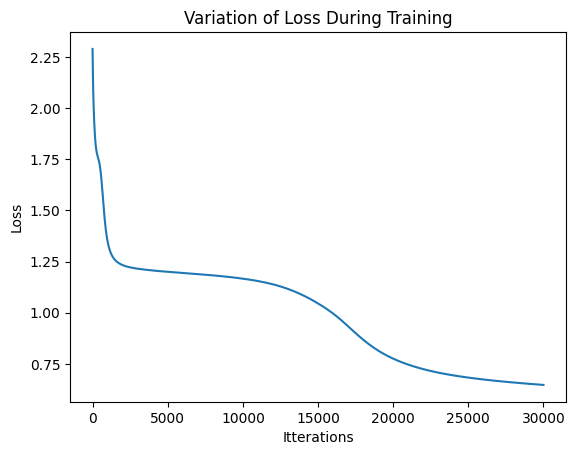

In [ ]:
import matplotlib.pyplot as plt

plt.plot(range(300), loss_arr)
plt.xlabel("Itterations (in thousands)")
plt.ylabel("Loss")
plt.title("Variation of Loss During Training")
plt.show()

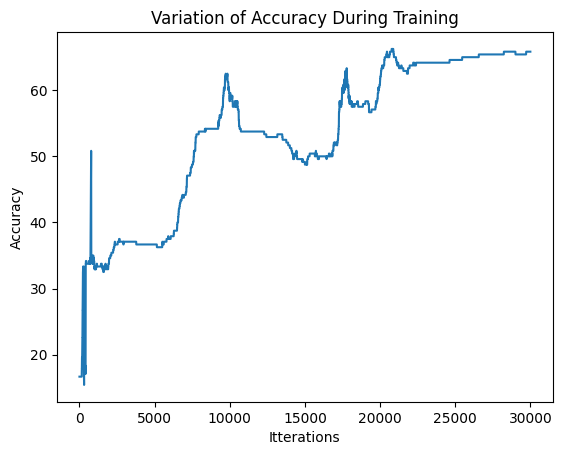

In [ ]:
plt.plot(range(300), acc_arr)
plt.xlabel("Itterations (in thousands)")
plt.ylabel("Accuracy")
plt.title("Variation of Accuracy During Training")
plt.show()